In [8]:
import numpy as np
import matplotlib.pyplot as plt
from designer_waveform.waveforms import SplitGaussianWaveform

In [9]:
# initialise random number generator
rng = np.random.default_rng(42)

In [10]:
# generate time axes
t_stim = np.linspace(0, 20, 1000)       # ms, stimulus time axis
bin_edges = np.arange(0, 21, 0.5)       # 0.5 ms PSTH bins
t_psth = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [11]:
# define mock simulation runner (will be replaced by real model call)
def run_simulation(waveform) -> np.ndarray:
    """
    Placeholder for the real model. Replace the body with your simulation call.
    Contract: receives a Waveform, returns a PSTH array aligned to t_psth.
    """
    # generate stimulation waveform
    stim = waveform(t_stim)

    # arbitrary scaling to get firing rates in a reasonable range (in Hz)
    rate = np.clip(stim, 0, None) * 80.0  

    # get PSTH by binning the rate into the specified bins
    dt_bin = bin_edges[1] - bin_edges[0]
    psth = np.array([
        rate[(t_stim >= bin_edges[i]) & (t_stim < bin_edges[i + 1])].mean() * dt_bin / 1000
        for i in range(len(bin_edges) - 1)
    ])

    return psth

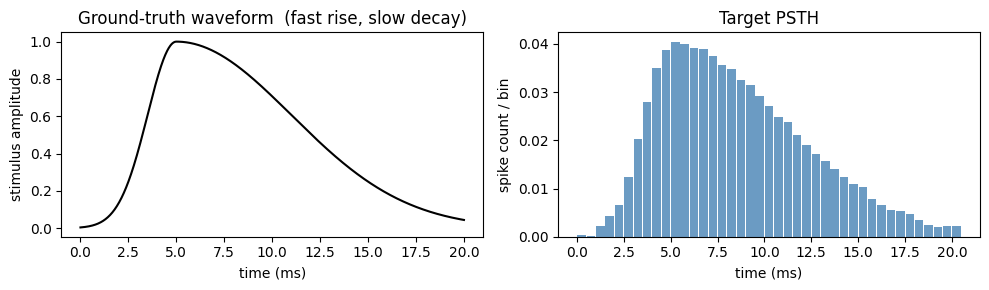

In [12]:
# generate ground-truth waveform to generate a target PSTH
true_waveform = SplitGaussianWaveform(
    amplitude=1.0,
    mu=5.0, sigma_rise=1.5, sigma_fall=6.0, baseline=0.0
)

# generate target PSTH from the true waveform, adding some noise to simulate experimental variability
target_psth = run_simulation(true_waveform)
target_psth += rng.normal(0, 5e-4, size=target_psth.shape)

# plot target PSTH
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t_stim, true_waveform(t_stim), 'k')
axes[0].set_xlabel('time (ms)')
axes[0].set_ylabel('stimulus amplitude')
axes[0].set_title('Ground-truth waveform  (fast rise, slow decay)')
axes[1].bar(t_psth, target_psth, width=0.45, color='steelblue', alpha=0.8)
axes[1].set_xlabel('time (ms)')
axes[1].set_ylabel('spike count / bin')
axes[1].set_title('Target PSTH')

plt.tight_layout()
plt.show()

Define objective function

In [14]:
PENALTY_WEIGHT = 1e4   # penalty weight for negative waveform values (tune this to balance MSE fit vs non-negativity constraint)

# define objective function for optimization: MSE between simulated and target PSTH, plus penalty for negative waveform values
def psth_mse(waveform) -> float:
    y = waveform(t_stim)
    psth = run_simulation(waveform)

    loss = np.mean((psth - target_psth) ** 2)

    # Soft non-negativity penalty: penalises any region where the waveform
    # dips below zero.  The optimizer can see this gradient and is pushed away
    # from the infeasible region, unlike hard-clipping which hides the violation.
    negativity = np.mean(np.clip(-y, 0, None) ** 2)
    loss += PENALTY_WEIGHT * negativity

    return float(loss)

Run optimisation

In [16]:
# initial guess: symmetric, wrong timescale
init_waveform = SplitGaussianWaveform(
    mu=8.0, sigma_rise=3.0, sigma_fall=3.0, baseline=0.0
)

# run optimisation using Nelder-Mead method
result_waveform, opt = init_waveform.optimise(
    psth_mse,
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-9, 'disp': True},
)

print(f"\nOptimised loss: {opt.fun:.6f}  ({opt.nit} iterations, success={opt.success})")
print(f"Min waveform value: {result_waveform(t_stim).min():.4f}  (should be >= 0)")
print("\nTrue waveform:     ", true_waveform)
print("Optimised waveform:", result_waveform)

Starting Nelder-Mead optimisation (5 params)
  Initial waveform: SplitGaussianWaveform(amplitude=1, mu=8, sigma_rise=3, sigma_fall=3, baseline=0)
  call   10 | best loss 3.013291e-05 | SplitGaussianWaveform(amplitude=1.04, mu=7.55, sigma_rise=3.13, sigma_fall=3.13, baseline=-0.000126)
  call   20 | best loss 2.289249e-05 | SplitGaussianWaveform(amplitude=1.05, mu=7.19, sigma_rise=3.31, sigma_fall=3.5, baseline=-0.000628)
  call   30 | best loss 1.836559e-05 | SplitGaussianWaveform(amplitude=1.01, mu=7.31, sigma_rise=3.23, sigma_fall=3.8, baseline=-0.000963)
  call   40 | best loss 1.542644e-05 | SplitGaussianWaveform(amplitude=0.999, mu=7.25, sigma_rise=3.42, sigma_fall=4.39, baseline=-0.00179)
  call   50 | best loss 1.477000e-05 | SplitGaussianWaveform(amplitude=0.967, mu=7.15, sigma_rise=3.47, sigma_fall=4.68, baseline=-0.00223)
  call   60 | best loss 1.416210e-05 | SplitGaussianWaveform(amplitude=0.957, mu=7.18, sigma_rise=3.35, sigma_fall=4.64, baseline=-0.00192)
  call   70 | be

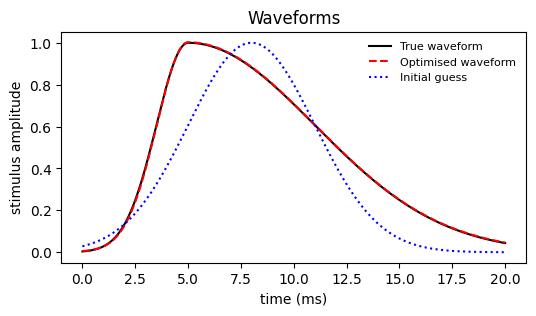

In [ ]:
# Plot results and initial guess
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(t_stim, true_waveform(t_stim), 'k', label='True waveform')
ax.plot(t_stim, result_waveform(t_stim), 'r--', label='Optimised waveform')
ax.plot(t_stim, init_waveform(t_stim), 'b:', label='Initial guess')
ax.set_xlabel('time (ms)')
ax.set_ylabel('stimulus amplitude')
ax.legend(frameon=False, fontsize=8)   